In [36]:
from pathlib import Path
import maboss
from neko.core.network import Network
from physicell_config import PhysiCellConfig
from physicell_config.config.embedded_signals_behaviors import (
    get_signals_behaviors,
    get_signal_by_name,
    get_behavior_by_name,
    update_signals_behaviors_context_from_config,
    get_expanded_signals,
    get_expanded_behaviors
)
from neko._outputs.exports import Exports

In [59]:
OUTPUT_DIR = Path("./outputs")
BNET_BASENAME = "network_1"
BND_PATH = OUTPUT_DIR / "model.bnd"
CFG_PATH = OUTPUT_DIR / "model.cfg"

OUTPUT_DIR.mkdir(exist_ok=True)

TNF_INPUT_CANDIDATES = ("TNF", "TNFRSF1A")
TNF_OUTPUT_BEHAVIOR_CANDIDATES = {
    "apoptosis": ("CASP8", "CASP3", "CASP7", "BAX"),
    "necrosis": ("MLKL", "RIPK3", "RIPK1"),
    "cycle_entry": ("NFKB1")
}

def get_network_node_names(network):
    if hasattr(network, "nodes") and "Genesymbol" in network.nodes.columns:
        return [
            str(node_name)
            for node_name in network.nodes["Genesymbol"].dropna().drop_duplicates().tolist()
        ]
    if hasattr(network, "network") and hasattr(network.network, "names"):
        return [str(node_name) for node_name in network.network.names]
    raise ValueError("Unable to extract node names from the generated network.")

def get_available_physicell_behaviors(config):
    update_signals_behaviors_context_from_config(config)
    return {
        entry.get("full_name", entry.get("name"))
        for entry in get_expanded_behaviors()
    }

def select_tnf_input_node(node_names):
    for candidate in TNF_INPUT_CANDIDATES:
        if candidate in node_names:
            return candidate
    raise ValueError(
        "The generated network does not contain a TNF-facing node that can be mapped to the TNF substrate. "
        f"Available nodes: {node_names}"
    )

def select_tnf_output_mappings(node_names, available_behaviors):
    output_mappings = []
    for behavior_name, candidate_nodes in TNF_OUTPUT_BEHAVIOR_CANDIDATES.items():
        if behavior_name not in available_behaviors:
            continue
        matched_node = next((node for node in candidate_nodes if node in node_names), None)
        if matched_node is not None:
            output_mappings.append((behavior_name, matched_node))
    return output_mappings



In [60]:
seed_nodes = ["TNF", "TNFRSF1A", "TRADD", "RIPK1", "CASP8", "NFKB1", "BAX", "BCL2"]

new_net1 = Network(seed_nodes, resources='omnipath')
new_net1.connect_nodes(only_signed=True, consensus_only=True)

In [61]:
new_net1.complete_connection(algorithm="bfs", connect_with_bias=False, only_signed=True, consensus=True)

In [62]:
new_net1.remove_bimodal_interactions()
new_net1.remove_disconnected_nodes()

In [63]:
for existing_bnet_path in Path(".").glob(f"{BNET_BASENAME}*.bnet"):
    existing_bnet_path.unlink()

exporter = Exports(new_net1)
exporter.export_bnet(f"./{BNET_BASENAME}.bnet")

exported_bnet_paths = sorted(
    Path(".").glob(f"{BNET_BASENAME}*.bnet"),
    key=lambda path: path.stat().st_mtime
 )

if not exported_bnet_paths:
    raise FileNotFoundError("No BNet file was generated by the exporter.")

active_bnet_path = exported_bnet_paths[-1]
print(f"Using exported BNet file: {active_bnet_path}")

Created BNet file: ./network_1_1.bnet
Generated 1 BNet files.
Using exported BNet file: network_1_1.bnet


In [64]:
maboss.bnet_to_bnd_and_cfg(str(active_bnet_path), str(BND_PATH), str(CFG_PATH))

In [65]:
masim = maboss.load(str(BND_PATH), str(CFG_PATH))

In [66]:
results = masim.run()

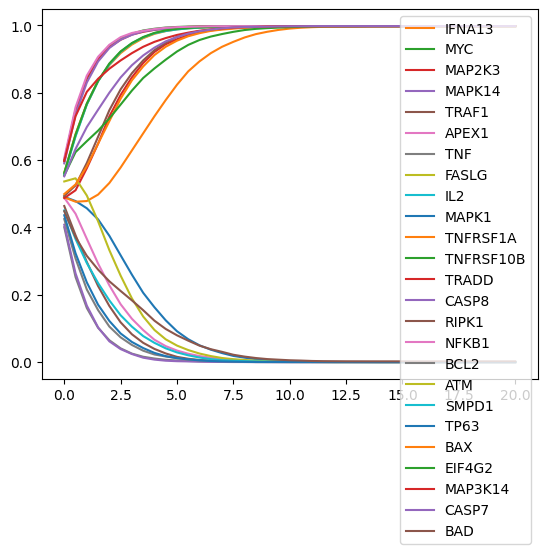

In [67]:
results.plot_node_trajectory(until=20)

In [68]:
# Create a new configuration
config = PhysiCellConfig()

# Set up simulation domain
config.domain.set_bounds(x_min=-500, x_max=500, y_min=-500, y_max=500)

# Add substrates
config.substrates.add_substrate(
    name="TNF", 
    diffusion_coefficient=100000.0,
    decay_rate=0.1
)

# Add cell type
config.cell_types.add_cell_type(
    name="cancer_cell",
)

In [69]:
network_node_names = get_network_node_names(new_net1)

config.physiboss.add_intracellular_model(
    "cancer_cell",
    "maboss",
    str(BND_PATH),
    str(CFG_PATH)
 )

In [70]:
tnf_input_node = select_tnf_input_node(network_node_names)

config.physiboss.add_intracellular_input(
    "cancer_cell",
    "TNF",
    tnf_input_node
 )

tnf_input_mapping = {
    "physicell_signal": "TNF",
    "intracellular_node": tnf_input_node
}
tnf_input_mapping

{'physicell_signal': 'TNF', 'intracellular_node': 'TNF'}

In [71]:
available_behaviors = get_available_physicell_behaviors(config)
tnf_output_mappings = select_tnf_output_mappings(network_node_names, available_behaviors)

for behavior_name, intracellular_node in tnf_output_mappings:
    config.physiboss.add_intracellular_output(
        "cancer_cell",
        behavior_name,
        intracellular_node
    )

mapping_summary = {
    "network_nodes": network_node_names,
    "input_mapping": tnf_input_mapping,
    "output_mappings": [
        {
            "physicell_behavior": behavior_name,
            "intracellular_node": intracellular_node
        }
        for behavior_name, intracellular_node in tnf_output_mappings
    ]
}

if not tnf_output_mappings:
    print("No supported TNF phenotype outputs were found in the generated network.")

mapping_summary

{'network_nodes': ['TNF',
  'TNFRSF1A',
  'TRADD',
  'RIPK1',
  'CASP8',
  'NFKB1',
  'BAX',
  'BCL2',
  'MAP2K3',
  'MAPK14',
  'TRAF1',
  'IFNA13',
  'SMPD1',
  'APEX1',
  'ATM',
  'MAPK1',
  'FASLG',
  'CASP7',
  'IL2',
  'TNFRSF10B',
  'MAP3K14',
  'TP63',
  'EIF4G2',
  'MYC',
  'BAD'],
 'input_mapping': {'physicell_signal': 'TNF', 'intracellular_node': 'TNF'},
 'output_mappings': [{'physicell_behavior': 'apoptosis',
   'intracellular_node': 'CASP8'},
  {'physicell_behavior': 'necrosis', 'intracellular_node': 'RIPK1'}]}

In [72]:
print(mapping_summary)
print(config.generate_xml())

{'network_nodes': ['TNF', 'TNFRSF1A', 'TRADD', 'RIPK1', 'CASP8', 'NFKB1', 'BAX', 'BCL2', 'MAP2K3', 'MAPK14', 'TRAF1', 'IFNA13', 'SMPD1', 'APEX1', 'ATM', 'MAPK1', 'FASLG', 'CASP7', 'IL2', 'TNFRSF10B', 'MAP3K14', 'TP63', 'EIF4G2', 'MYC', 'BAD'], 'input_mapping': {'physicell_signal': 'TNF', 'intracellular_node': 'TNF'}, 'output_mappings': [{'physicell_behavior': 'apoptosis', 'intracellular_node': 'CASP8'}, {'physicell_behavior': 'necrosis', 'intracellular_node': 'RIPK1'}]}
<PhysiCell_settings version="devel-version">

    <domain>
        <x_min>-500</x_min>
        <x_max>500</x_max>
        <y_min>-500</y_min>
        <y_max>500</y_max>
        <z_min>-10</z_min>
        <z_max>10</z_max>
        <dx>20</dx>
        <dy>20</dy>
        <dz>20</dz>
        <use_2D>true</use_2D>
    </domain>

    <overall>
        <max_time units="min">8640.0</max_time>
        <time_units>min</time_units>
        <space_units>micron</space_units>
        <dt_diffusion units="min">0.01</dt_diffusion>
   